In [1]:
!pip uninstall -y transformers
!rm -rf /opt/conda/lib/python3.10/site-packages/transformers*
!rm -rf /opt/conda/lib/python3.10/site-packages/~ransformers*
!rm -rf /usr/local/lib/python3.12/dist-packages/bitsandbytes*
!rm -rf /usr/local/lib/python3.12/dist-packages/*bitsandbytes*

Found existing installation: transformers 5.7.0
Uninstalling transformers-5.7.0:
  Successfully uninstalled transformers-5.7.0


In [2]:
!pip uninstall -y bitsandbytes

In [3]:
!pip install --no-cache-dir bitsandbytes
!pip install transformers peft accelerate datasets bitsandbytes
!pip uninstall -y huggingface_hub
!pip install --no-cache-dir huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 230.6 MB/s eta 0:00:00a 0:00:01
  Using cached transformers-5.7.0-py3-none-any.whl.metadata (33 kB)
Using cached transformers-5.7.0-py3-none-any.whl (10.5 MB)
Found existing installation: huggingface_hub 1.13.0
Uninstalling huggingface_hub-1.13.0:
  Successfully uninstalled huggingface_hub-1.13.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 12.7 MB/s eta 0:00:00 0:00:01


In [4]:
import torch, bitsandbytes as bnb
print("GPU:", torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)
print("bnb:", bnb.__version__)
import huggingface_hub
print(huggingface_hub.__version__)

GPU: Tesla P100-PCIE-16GB
CUDA: 12.6
bnb: 0.49.2


In [ ]:
from huggingface_hub import login
import torch
import os
from datasets import Dataset, concatenate_datasets
from peft import PeftModel
from transformers import AutoModelForCausalLM, TrainingArguments, BitsAndBytesConfig,AutoTokenizer
os.environ["HF_TOKEN"] = ""
print("GPU:", torch.cuda.get_device_name(0))
model_id="Qwen/Qwen2.5-1.5B"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16)
print(bnb_config)
model = AutoModelForCausalLM.from_pretrained(model_id,quantization_config=bnb_config,device_map="auto",trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
print(type(model))

GPU: Tesla P100-PCIE-16GB
BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "float16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": false,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}



config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

<class 'transformers.models.qwen2.modeling_qwen2.Qwen2ForCausalLM'>


In [6]:
from peft import prepare_model_for_kbit_training
model=prepare_model_for_kbit_training(model)
model.config.use_cache = False
model

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear4bit(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear4bit(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear4bit(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear4bit(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear4bit(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear4bit(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear4bit(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1

In [7]:
from peft import LoraConfig, get_peft_model
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"], 
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
    )

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 1,089,536 || all params: 1,544,803,840 || trainable%: 0.0705


In [8]:
from datasets import load_dataset
from datasets import concatenate_datasets
dataset = load_dataset("csv", data_files="/kaggle/input/datasets/technoworld/jobs-export/jobs_export.csv")
new_dataset=load_dataset("csv", data_files="/kaggle/input/datasets/technoworld/geocode/jobs_geocodio.csv")
print(dataset)
print(dataset["train"][0])

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['job_id', 'job_title', 'store_city', 'store_state', 'description', 'job_url'],
        num_rows: 606
    })
})
{'job_id': 1, 'job_title': 'Assistant Store Manager- AT&T', 'store_city': 'Brownsville', 'store_state': 'TN', 'description': "Look around. Does it seem like we're nearly everywhere? That's because we practically are! With 2000+ AT&T stores coast-to-coast, Prime Communications is one of AT&T's largest authorized retailers in the United States, and we want you to join us as an Assistant Store Manager! An Assistant Store Manager (ASM) is an ambassador to our extraordinarily large base of customers nationwide. As an ASM, you will serve the customer by demonstrating AT&T's vast array of products, services, and entertainment options, and offering them personal, valuable solutions to fit their needs. Because we strive for the best, we offer amongst the best. You will be rewarded for your efforts with high earning potential -- our 

In [9]:
combined = concatenate_datasets([
    dataset["train"],
    new_dataset["train"]
])

In [10]:
def format_example(example):
    return {
        "text": f"""### Instruction:
Generate a job description.

### Input:
Job Title: {example['job_title']}
Location: {example['store_city']}, {example['store_state']}

### Response:
{example['description']}"""
    }

dataset = dataset.map(format_example)
dataset

Map:   0%|          | 0/606 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['job_id', 'job_title', 'store_city', 'store_state', 'description', 'job_url', 'text'],
        num_rows: 606
    })
})

In [11]:
print(dataset["train"][0]["text"])

### Instruction:
Generate a job description.

### Input:
Job Title: Assistant Store Manager- AT&T
Location: Brownsville, TN

### Response:
Look around. Does it seem like we're nearly everywhere? That's because we practically are! With 2000+ AT&T stores coast-to-coast, Prime Communications is one of AT&T's largest authorized retailers in the United States, and we want you to join us as an Assistant Store Manager! An Assistant Store Manager (ASM) is an ambassador to our extraordinarily large base of customers nationwide. As an ASM, you will serve the customer by demonstrating AT&T's vast array of products, services, and entertainment options, and offering them personal, valuable solutions to fit their needs. Because we strive for the best, we offer amongst the best. You will be rewarded for your efforts with high earning potential -- our current full-time ASM's earn an average of $35,000 in total compensation in the first year when successfully meeting or exceeding sales goals. Our top s

In [12]:
model.save_pretrained("vishnu_ai_5.1_lora")
tokenizer.save_pretrained("vishnu_ai_5.1_lora")

('vishnu_ai_5.1_lora/tokenizer_config.json',
 'vishnu_ai_5.1_lora/chat_template.jinja',
 'vishnu_ai_5.1_lora/tokenizer.json')

In [13]:
from transformers import AutoModelForCausalLM

base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B",
    device_map="auto",
    trust_remote_code=True
)
from peft import PeftModel

model = PeftModel.from_pretrained(
    base_model,
    "vishnu_ai_5.1_lora"
)
print(type(model))
model = model.merge_and_unload()
model.save_pretrained("vishnu_ai_5.1_full")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

<class 'peft.peft_model.PeftModelForCausalLM'>


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

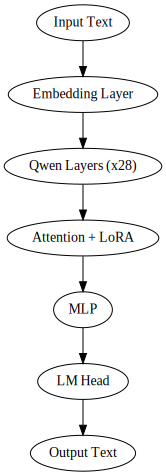

In [14]:
!pip install graphviz
from graphviz import Digraph

dot = Digraph()

dot.node('A', 'Input Text')
dot.node('B', 'Embedding Layer')
dot.node('C', 'Qwen Layers (x28)')
dot.node('D', 'Attention + LoRA')
dot.node('E', 'MLP')
dot.node('F', 'LM Head')
dot.node('G', 'Output Text')

dot.edges([
    ('A','B'), ('B','C'),
    ('C','D'), ('D','E'),
    ('E','F'), ('F','G')
])

dot.render('model_architecture', format='png', view=True)
dot

In [62]:
prompt = """### Instruction:
Generate a job description.

### Input:
Tell me number of jobs sugarland

### Response:
"""

In [16]:
import torch
torch.cuda.empty_cache()

Error: no "view" mailcap rules found for type "image/png"
/usr/bin/xdg-open: 882: www-browser: not found
/usr/bin/xdg-open: 882: links2: not found
/usr/bin/xdg-open: 882: elinks: not found
/usr/bin/xdg-open: 882: links: not found
/usr/bin/xdg-open: 882: lynx: not found
/usr/bin/xdg-open: 882: w3m: not found
xdg-open: no method available for opening 'model_architecture.png'


In [63]:
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B",
    device_map={"": 0},
    trust_remote_code=True
)

inputs = tokenizer(prompt, return_tensors="pt").to(base_model.device)
output = base_model.generate(**inputs, max_new_tokens=200)

print("BASE MODEL:\n", tokenizer.decode(output[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


BASE MODEL:
 ### Instruction:
Generate a job description.

### Input:
Tell me number of jobs sugarland

### Response:
Here is a job description for a job in Sugarland, Texas:

Job Title: Sales Representative

Location: Sugarland, Texas

Job Description:

We are seeking a motivated and enthusiastic Sales Representative to join our team in Sugarland, Texas. The ideal candidate will have a strong background in sales and be able to effectively communicate with customers to drive sales and revenue growth.

Responsibilities:

- Develop and maintain relationships with customers to identify and pursue sales opportunities
- Create and execute sales plans and strategies to meet or exceed sales targets
- Provide exceptional customer service to ensure customer satisfaction and loyalty
- Stay up-to-date with industry trends and best practices to improve sales performance
- Collaborate with other team members to achieve shared goals and objectives

Requirements:

- Bachelor's degree in Marketing, Sa

In [33]:
!pip install llama-cpp-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 MB 26.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00
  Created wheel for llama-cpp-python: filename=llama_cpp_python-0.3.22-py3-none-linux_x86_64.whl size=18311031 sha256=e40086a10e166bf385a15f95147265c8f876abe2af05a8a6850ee233cd6723a5
  Stored in directory: /root/.cache/pip/wheels/c2/31/5c/91da2c279c89f857a64ce732ef0d26f5888a38ac9022526607
Successfully built llama-cpp-python


In [37]:
!git clone https://github.com/ggerganov/llama.cpp
%cd llama.cpp
!pip install -r requirements.txt

Cloning into 'llama.cpp'...
remote: Enumerating objects: 91892, done.
remote: Counting objects: 100% (191/191), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 91892 (delta 141), reused 70 (delta 70), pack-reused 91701 (from 3)
Receiving objects: 100% (91892/91892), 380.71 MiB | 33.72 MiB/s, done.
Resolving deltas: 100% (65146/65146), done.
/kaggle/working/llama.cpp
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu, https://download.pytorch.org/whl/nightly, https://download.pytorch.org/whl/cpu, https://download.pytorch.org/whl/nightly, https://download.pytorch.org/whl/cpu, https://download.pytorch.org/whl/nightly
Ignoring torch: markers 'platform_machine == "s390x"' don't match your environment
Ignoring torch: markers 'platform_machine == "s390x"' don't match your environment
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.0 MB/s eta 0:00:00

In [72]:
!python convert_hf_to_gguf.py \
   --model qwen_model \
  --outfile model-f16.gguf \
  --outtype f16\
  /kaggle/working/vishnu_ai_5.1_full

INFO:hf-to-gguf:Loading model: vishnu_ai_5.1_full
INFO:numexpr.utils:NumExpr defaulting to 4 threads.
INFO:hf-to-gguf:Model architecture: Qwen2ForCausalLM
INFO:hf-to-gguf:gguf: indexing model part 'model.safetensors'
INFO:gguf.gguf_writer:gguf: This GGUF file is for Little Endian only
INFO:hf-to-gguf:Exporting model...
INFO:hf-to-gguf:token_embd.weight,         torch.bfloat16 --> F16, shape = {1536, 151936}
INFO:hf-to-gguf:blk.0.attn_norm.weight,    torch.bfloat16 --> F32, shape = {1536}
INFO:hf-to-gguf:blk.0.ffn_down.weight,     torch.bfloat16 --> F16, shape = {8960, 1536}
INFO:hf-to-gguf:blk.0.ffn_gate.weight,     torch.bfloat16 --> F16, shape = {1536, 8960}
INFO:hf-to-gguf:blk.0.ffn_up.weight,       torch.bfloat16 --> F16, shape = {1536, 8960}
INFO:hf-to-gguf:blk.0.ffn_norm.weight,     torch.bfloat16 --> F32, shape = {1536}
INFO:hf-to-gguf:blk.0.attn_k.bias,         torch.bfloat16 --> F32, shape = {256}
INFO:hf-to-gguf:blk.0.attn_k.weight,       torch.bfloat16 --> F16, shape = {1536

In [77]:
%cd /kaggle/working/llama.cpp

/kaggle/working/llama.cpp


In [78]:
!make

Makefile:6: *** Build system changed:
 The Makefile build has been replaced by CMake.

 For build instructions see:
 https://github.com/ggml-org/llama.cpp/blob/master/docs/build.md

.  Stop.


In [79]:
!cmake -B build
!cmake --build build --config Release

-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
CMAKE_BUILD_TYPE=Release
-- Found Git: /usr/bin/git (found version "2.34.1")
-- The ASM compiler identification is GNU
-- Found assembler: /usr/bin/cc
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD - Success
-- Found Threads: TRUE
-- Warning: ccache not found - consider installing it for faster compilation or disable this warning with GGML_CCACHE=OFF
-- CMAKE_SYSTEM_PROCESSOR: x86_64
-- GGML_SYSTEM_ARCH: x86
-- Including CPU backend
-- Found OpenMP_C: 

In [93]:
!ls
!ls bin/llama-results

AGENTS.md		      convert_llama_ggml_to_gguf.py  mypy.ini
AUTHORS			      convert_lora_to_gguf.py	     pocs
benches			      docs			     poetry.lock
build			      examples			     pyproject.toml
build-xcframework.sh	      flake.lock		     pyrightconfig.json
ci			      flake.nix			     README.md
CLAUDE.md		      ggml			     requirements
cmake			      gguf-py			     requirements.txt
CMakeLists.txt		      grammars			     scripts
CMakePresets.json	      include			     SECURITY.md
CODEOWNERS		      LICENSE			     src
common			      licenses			     tests
CONTRIBUTING.md		      Makefile			     tools
convert_hf_to_gguf.py	      media			     ty.toml
convert_hf_to_gguf_update.py  models			     vendor
ls: cannot access 'bin/llama-results': No such file or directory


In [92]:
!chmod +x llama-results

chmod: cannot access 'llama-results': No such file or directory


In [94]:
!./build/bin/llama-quantize model-f16.gguf model-q4.gguf q4_k_m

llama_print_build_info: build = 9035 (d5003b6e4)
llama_print_build_info: built with GNU 11.4.0 for Linux x86_64
main: quantizing 'model-f16.gguf' to 'model-q4.gguf' as Q4_K_M
gguf_init_from_file: failed to open GGUF file 'model-f16.gguf' (No such file or directory)
llama_model_quantize: failed to quantize: llama_model_loader: failed to load model from model-f16.gguf
main: failed to quantize model from 'model-f16.gguf'
